In [7]:
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz

import sys
sys.path.append("../../")
from testing_scripts.qaoa_utils import QAOASolver, evaluate_energy

import numpy as np
import pcbo_utils
from qiskit.quantum_info import SparsePauliOp

In [8]:
n_qubits = 20
feature_set, feature_to_idx, first_corr_arr, second_corr_arr, third_corr_arr = pcbo_utils.load_features_and_corr_files(f'sampled_{n_qubits}_features_subproblem_1')

pcbo_obj = pcbo_utils.create_three_body_cubo(
    feature_set,
    first_corr_arr,
    second_corr_arr,
    third_corr_arr,
    feature_to_idx,
    select_n_features=4,
)

pubo = {key: float(value) for key, value in pcbo_obj.to_pubo().items()}

In [9]:
def convert_pubo_to_ising(hypergraph: dict) -> list[tuple[str, float]]:
    """Convert a hypergraph dictionary to a list of Pauli strings with weights."""
    n = n_qubits # Number of qubits
    pauli_list = []

    for edge, weight in hypergraph.items():
        if edge:  # Ensure the edge is not empty
            # Create a Pauli string with "I" for all qubits
            paulis = ["I"] * n
            # Replace "I" with "Z" for qubits in the edge
            for node in edge:
                paulis[node] = "Z"
            # Append the reversed Pauli string and weight to the list
            pauli_list.append(("".join(paulis[::-1]), weight))

    return pauli_list

max_cut_paulis = convert_pubo_to_ising(pubo)
cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
paulis,coeffs = cost_hamiltonian.paulis.to_labels(),cost_hamiltonian.coeffs.real
cost_hamiltonian

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIIIZIIIIII', 'IIIIIIIIIIIIZIIIIIII', 'IIIIIIIIIIIZIIIIIIII', 'IIIIIIIIIIZIIIIIIIII', 'IIIIIIIIIZIIIIIIIIII', 'IIIIIIIIZIIIIIIIIIII', 'IIIIIIIZIIIIIIIIIIII', 'IIIIIIZIIIIIIIIIIIII', 'IIIIIZIIIIIIIIIIIIII', 'IIIIZIIIIIIIIIIIIIII', 'IIIZIIIIIIIIIIIIIIII', 'IIZIIIIIIIIIIIIIIIII', 'IZIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIIIIIIZIZ', 'IIIIIIIIIIIIIIIIZIIZ', 'IIIIIIIIIIIIIIIZIIIZ', 'IIIIIIIIIIIIIIZIIIIZ', 'IIIIIIIIIIIIIZIIIIIZ', 'IIIIIIIIIIIIZIIIIIIZ', 'IIIIIIIIIIIZIIIIIIIZ', 'IIIIIIIIIIZIIIIIIIIZ', 'IIIIIIIIIZIIIIIIIIIZ', 'IIIIIIIIZIIIIIIIIIIZ', 'IIIIIIIZIIIIIIIIIIIZ', 'IIIIIIZIIIIIIIIIIIIZ', 'IIIIIZIIIIIIIIIIIIIZ', 'IIIIZIIIIIIIIIIIIIIZ', 'IIIZIIIIIIIIIIIIIIIZ', 'IIZIIIIIIIIIIIIIIIIZ', 'IZIIIIIIIIIIIIIIIIIZ', 'ZIIIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIZZI', 'IIIIIIIIIIIIIIIIZIZI', '

In [10]:
reps=2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
circuit

In [11]:
teague_qaoa = QAOASolver(cost_hamiltonian,circuit,"CPU")
teague_qaoa.prepare_circuit()
teague_qaoa.pcirc.num_parameters

2740

In [12]:
# Solve with classical Eigensolver for comparison
exact_solution = teague_qaoa.evaluate_exact_energy()

Exact Energy from Eigensolver: -32023.76072807837


In [13]:
# we can perform CAFQA by using the main optimization function "claptonize"
teague_qaoa.run_CAFQA(n_gens=5)

STARTING ROUND 0




started GA at id 1 with 32 procs

started GA at id 2 with 32 procs

started GA at id 3 with 32 procs

started GA at id None with 32 procs

GA parameters used for this experiment:
  num_generations=2
  num_parents_mating=20
  population_size=100
  num_genes=2740
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
GA parameters used for this experiment:
  num_generations=2
  num_parents_mating=20
  population_size=100
  num_genes=2740
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
GA parameters used for this experiment:
  num_generations=2
  num_parents_mating=20
  population_size=100
  num_genes=2740
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  cros

In [14]:
teague_qaoa.energy_best

np.float64(0.0)

In [ ]:
cafqa_angles = [param * np.pi/2 for param in teague_qaoa.ks_best]

In [ ]:
energies = [teague_qaoa.evaluate_energy(teague_qaoa.pcirc,teague_qaoa.cost_hamiltonian,cafqa_angles,err=1e-3) for _ in range(10)]
average_energy = np.mean(energies)
print(f"Average CAFQA Qiskit Energy: {average_energy}")

Average CAFQA Qiskit Energy: -76.56554600925438


In [ ]:
# Random Initalization
random_angles = np.random.random(len(teague_qaoa.ks_best))
random_energies = [evaluate_energy(teague_qaoa.pcirc, cost_hamiltonian, random_angles) for _ in range(10)]
min_energy = min(random_energies)
print(f"Minimum Energy found with Random initialization over 100 runs: {min_energy}")

Minimum Energy found with Random initialization over 100 runs: 3106.557163046207


In [ ]:
cafqa_result,cafqa_iteration_vals = teague_qaoa.run_qaoa(cafqa_angles,max_iters=10,err=1e-3)
random_result,random_iteration_vals = teague_qaoa.run_qaoa(random_angles,max_iters=10,err=1e-3)

In [ ]:
cafqa_result

 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 2
     fun: -1189.4985071275612
       x: [ 2.571e+00  2.571e+00 ...  0.000e+00  3.142e+00]
    nfev: 10
   maxcv: 0.0

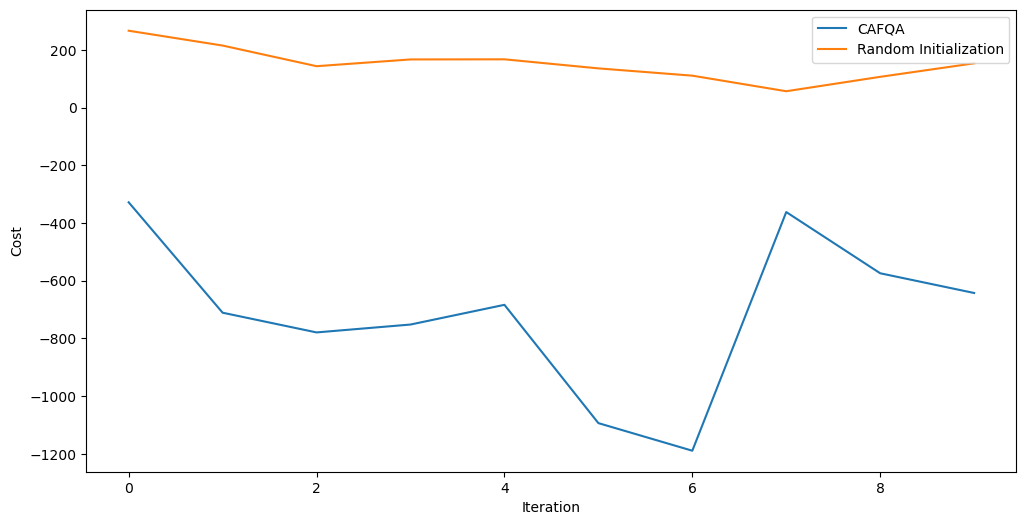

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(cafqa_iteration_vals, label="CAFQA")
plt.plot(random_iteration_vals, label="Random Initialization")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()